In [1]:
import pandas as pd
import warnings as ws

ws.filterwarnings('ignore')

In [2]:
dataset= pd.read_csv("PrePlacement.csv")
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


1) Replace the NaN values with correct value. And justify why you have chosen the same.

In [39]:
dataset.isna().sum()
dataset.fillna(0, inplace=True)
#1) Replace the missing value with central tendency-(Numeric columns → Median, Categorical columns → Mode)
#2) Entire Row delete
#3) Respective to the problem, Have to replace the missing values
#4) Consider this as a semi supervised, create a model, so that we can predict the missing values.
# Here salary is sensitive columns, if not placed, definitely the salary zero, so it converts null to zero

2) How many of them are not placed?

In [3]:
dataset[dataset['status']=='Not Placed']
# How many of them are not placed? 67

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
3,4,M,56.0,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,0.0
5,6,M,55.0,Others,49.80,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,0.0
6,7,F,46.0,Others,49.20,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,0.0
9,10,M,58.0,Central,70.00,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,0.0
12,13,F,47.0,Central,55.00,Others,Science,65.00,Comm&Mgmt,No,62.00,Mkt&HR,65.04,Not Placed,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,199,F,67.0,Central,70.00,Central,Commerce,65.00,Others,No,88.00,Mkt&HR,71.96,Not Placed,0.0
201,202,M,54.2,Central,63.00,Others,Science,58.00,Comm&Mgmt,No,79.00,Mkt&HR,58.44,Not Placed,0.0
206,207,M,41.0,Central,42.75,Central,Science,60.00,Comm&Mgmt,No,97.00,Mkt&Fin,53.39,Not Placed,0.0
208,209,F,43.0,Central,60.00,Others,Science,65.00,Comm&Mgmt,No,92.66,Mkt&HR,62.92,Not Placed,0.0


In [4]:
dataset[dataset['status']=='Placed']

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,210,M,62.00,Central,72.00,Central,Commerce,65.00,Comm&Mgmt,No,67.0,Mkt&Fin,56.49,Placed,216000.0
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0


3. Find the reason for non placement from the dataset?

In [5]:
from scipy.stats import ttest_ind
placed= dataset[dataset['status']=='Placed']['mba_p']
not_placed= dataset[dataset['status']=='Not Placed']['mba_p']
ttest_ind(placed, not_placed)

TtestResult(statistic=np.float64(1.1259706009659818), pvalue=np.float64(0.2614450019774862), df=np.float64(213.0))

In [6]:
from scipy.stats import ttest_ind
placed=dataset[dataset['status']=='Placed']['etest_p']
not_placed= dataset[dataset['status']=='Not Placed']['etest_p']
ttest_ind(placed, not_placed)

TtestResult(statistic=np.float64(1.8781977946559039), pvalue=np.float64(0.061720381110174236), df=np.float64(213.0))

In [7]:
from scipy.stats import ttest_ind
placed=dataset[dataset['status']=='Placed']['degree_p']
not_placed= dataset[dataset['status']=='Not Placed']['degree_p']
ttest_ind(placed, not_placed)

TtestResult(statistic=np.float64(8.012038637786501), pvalue=np.float64(7.321180177806617e-14), df=np.float64(213.0))

In [8]:

from scipy.stats import ttest_ind
placed=dataset[dataset['status']=='Placed']['hsc_p']
not_placed= dataset[dataset['status']=='Not Placed']['hsc_p']
ttest_ind(placed, not_placed)

TtestResult(statistic=np.float64(8.266869768369684), pvalue=np.float64(1.4706851062538955e-14), df=np.float64(213.0))

In [9]:

from scipy.stats import ttest_ind
placed=dataset[dataset['status']=='Placed']['ssc_p']
not_placed= dataset[dataset['status']=='Not Placed']['ssc_p']
ttest_ind(placed, not_placed)

TtestResult(statistic=np.float64(11.173294337111484), pvalue=np.float64(4.115201043884438e-23), df=np.float64(213.0))

In [10]:
#overall compare mba_p, etest_p, degree_p, hsc_p, ssc_p. Based on their p values - Placement is mainly influenced by earlier academic performance
#(10th, 12th, degree marks), while MBA performance does not show a meaningful impact. The employability test has only a weak or uncertain effect.

4. What kind of relation between salary and mba_p

In [12]:
dataset.iloc[:, 1:].corr(numeric_only=True)

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.513478,0.538686,0.261993,0.388478,0.558475
hsc_p,0.513478,1.000000,0.434606,0.240775,0.348452,0.459424
degree_p,0.538686,0.434606,1.000000,0.227147,0.402376,0.423762
etest_p,0.261993,0.240775,0.227147,1.000000,0.218055,0.186775
mba_p,0.388478,0.348452,0.402376,0.218055,1.000000,0.141417
salary,0.558475,0.459424,0.423762,0.186775,0.141417,1.000000


In [ ]:
# Salary and MBA_p correlation is 0.141417
# Here 0.1 is close to Zero and No linear relationship.

5. Which specialization is getting minimum salary?

In [53]:
dataset.groupby('specialisation')['salary'].mean().sort_values().head(1)

specialisation
Mkt&HR    150842.105263
Name: salary, dtype: float64

6. How many of them getting above 500000 salary?

In [14]:
dataset[dataset['salary']>=500000]

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
77,78,M,64.00,Others,80.00,Others,Science,65.00,Sci&Tech,Yes,69.00,Mkt&Fin,57.65,Placed,500000.0
119,120,M,60.80,Central,68.40,Central,Commerce,64.60,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,706250.0
150,151,M,71.00,Central,58.66,Central,Science,58.00,Sci&Tech,Yes,56.00,Mkt&Fin,61.30,Placed,690000.0
163,164,M,63.00,Others,67.00,Others,Science,64.00,Sci&Tech,No,75.00,Mkt&Fin,66.46,Placed,500000.0
174,175,M,73.24,Others,50.83,Others,Science,64.27,Sci&Tech,Yes,64.00,Mkt&Fin,66.23,Placed,500000.0
177,178,F,73.00,Central,91.15,Others,Commerce,79.00,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0


7. Test the Analysis of Variance between etest_p and mba_p at signifance
level 5%.(Make decision using Hypothesis Testing)

In [16]:
import scipy.stats as stats
stats.f_oneway(dataset['etest_p'], dataset['mba_p'])

F_onewayResult(statistic=np.float64(98.64487057324706), pvalue=np.float64(4.672547689133748e-21))

In [ ]:
#P value = 0.000000000000000000004672547689133748
# it P value < 0.05, reject the null hypothesis and having significant changes

8. Test the similarity between the degree_t(Sci&Tech) and specialisation(
Mkt&HR) with respect to salary at significance level of 5%.(Make
decision using Hypothesis Testing)

In [17]:
import scipy.stats as stats
degree= dataset[dataset["degree_t"]=='Sci&Tech']["salary"]
specil=dataset[dataset["specialisation"]=='Mkt&HR']["salary"]
ttest_ind(degree, specil)

TtestResult(statistic=np.float64(2.692041243555374), pvalue=np.float64(0.007897969943471191), df=np.float64(152.0))

In [ ]:
# Pvalue = 0.007897969943471191
# Pvalue< 0.05 so the degree_t(Sci&Tech) and specialisation(Mkt&HR) having significant changes and reject null hypothesis

9. Convert the normal distribution to standard normal distribution for
salary column

In [20]:
from scipy.stats import zscore
dataset['salary_zscore'] = zscore(dataset['salary'])
dataset
#here every salary zscore convert between range of small values

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,salary_zscore
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0,0.482708
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0,0.015904
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0,0.349335
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0,-1.317822
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0,1.516345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0,1.349629
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0,0.516051
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0,0.649424
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0,0.042578


10. What is the probability Density Function of the salary range from
700000 to 900000?

In [22]:
mean = dataset['salary'].mean()
std= dataset['salary'].std()
from scipy.stats import norm
probability= norm.cdf(900000, mean,std)-norm.cdf(700000, mean, std) 
probability

np.float64(0.00041377631316941166)

In [24]:
mean = dataset['salary'].mean()
std= dataset['salary'].std()
from scipy.stats import norm
startrangePDF = norm.pdf(700000, mean,std)
endrangePDF = norm.pdf(900000, mean,std)
print (startrangePDF,endrangePDF )

9.954477772341963e-09 4.80871130806718e-11


11. Test the similarity between the degree_t(Sci&Tech)with respect to
etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis
Testing)

In [26]:
import scipy.stats as stats
degree= dataset[dataset["degree_t"]=='Sci&Tech']["etest_p"]
specil=dataset[dataset["degree_t"]=='Sci&Tech']["mba_p"]
ttest_ind(degree, specil)

TtestResult(statistic=np.float64(4.532000225151251), pvalue=np.float64(1.4289217003775655e-05), df=np.float64(116.0))

In [ ]:
# P values = 0.00001429
# Here p<0.05 so degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5% are significantly differ and reject null hypothesis

12. Which parameter is highly correlated with salary?

In [36]:
dataset.iloc[:, 1:].corr(numeric_only=True)
# Here Salary is highly coreleated to ssc_p = 0.558475	

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary,salary_zscore
ssc_p,1.000000,0.513478,0.538686,0.261993,0.388478,0.558475,0.558475
hsc_p,0.513478,1.000000,0.434606,0.240775,0.348452,0.459424,0.459424
degree_p,0.538686,0.434606,1.000000,0.227147,0.402376,0.423762,0.423762
etest_p,0.261993,0.240775,0.227147,1.000000,0.218055,0.186775,0.186775
mba_p,0.388478,0.348452,0.402376,0.218055,1.000000,0.141417,0.141417
salary,0.558475,0.459424,0.423762,0.186775,0.141417,1.000000,1.000000
salary_zscore,0.558475,0.459424,0.423762,0.186775,0.141417,1.000000,1.000000


13. plot any useful graph and explain it.

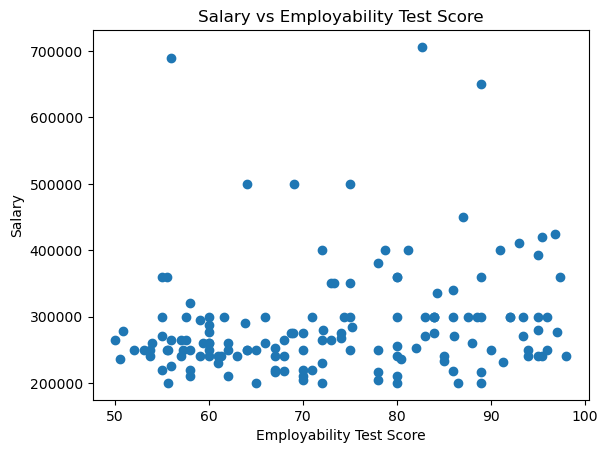

In [38]:
import matplotlib.pyplot as plt
placed_data = dataset[dataset['status'] == 'Placed']

plt.scatter(placed_data['etest_p'], placed_data['salary'])
plt.xlabel("Employability Test Score")
plt.ylabel("Salary")
plt.title("Salary vs Employability Test Score")
plt.show()